In [46]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

In [45]:
def fit_fp_decay(beta, energy, d_energy, save_plot=False):
    # fit the exponential energy decaying of free projection energy

    def exp_plateau(beta, E_inf, A, gamma):
        return E_inf + A * np.exp(-gamma * beta)

    # Initial guesses: E_inf ~ last points, A ~ E(0)-E_inf, gamma ~ 1
    p0 = [energy[-1], energy[0]-energy[-1], 1]

    popt, pcov = curve_fit(exp_plateau, beta, energy, p0=p0,
                        sigma=d_energy, absolute_sigma=True,
                        maxfev=10000)

    E_inf, A, gamma = popt
    perr = np.sqrt(np.diag(pcov))
    dE_inf, dA, dgamma = perr

    # Report
    print("=" * 80)
    print("  Exponential-Energy Cooling fit:  E(beta) = E_inf + A exp(-Gamma*beta)")
    print("=" * 80)
    print(f"  E_inf   = {E_inf:.6f} ± {dE_inf:.6f}")
    print(f"  A       = {A:.6f} ± {dA:.6f}")
    print(f"  Gamma   = {gamma:.4f} ± {dgamma:.4f}")
    print(f"  System cooled to about 37% initial Energy gap at beta = {1/gamma:.4f} a.u. (1/Gamma)")
    print(f"  System considered fully cooled at about beta = [{3/gamma:.4f}, {5/gamma:.4f}] a.u.")
    print("=" * 80)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

    beta_fine = np.linspace(0, beta[-1] * 1.05, 300)
    ax1.errorbar(beta, energy, yerr=d_energy, fmt='o', ms=4, capsize=3,
                color='C0', label='Data')
    ax1.plot(beta_fine, exp_plateau(beta_fine, *popt), '-', color='C1',
            label=rf'Fit: E($\beta$)={E_inf:.2f}+{A:.2f}exp(-{gamma:.2f}$\beta$)')
    ax1.axhline(E_inf, ls='--', color='C2', alpha=0.7,
                label=rf' $E_\infty$={E_inf:.5f}±{dE_inf:.5f}')
    ax1.fill_between(beta_fine, E_inf - dE_inf, E_inf + dE_inf,
                    color='C2', alpha=0.15)
    ax1.set_ylabel('Energy')
    ax1.set_title('Imaginary-time cooling curve')
    ax1.legend(fontsize=9)

    # Residuals
    residuals = (energy - exp_plateau(beta, *popt)) / d_energy
    ax2.errorbar(beta, residuals, yerr=1, fmt='o', ms=4, capsize=3, color='C0')
    ax2.axhline(0, ls='-', color='gray', lw=0.8)
    ax2.axhline(2, ls=':', color='gray', lw=0.6)
    ax2.axhline(-2, ls=':', color='gray', lw=0.6)
    ax2.set_xlabel(r'Imaginary time  $\beta$')
    ax2.set_ylabel(r'Residual ($\sigma$)')
    plt.tight_layout()
    if save_plot:
        plt.savefig('./fp_energy_decay.png', dpi=150)
    plt.close(fig) # don't show plot

    return E_inf, dE_inf

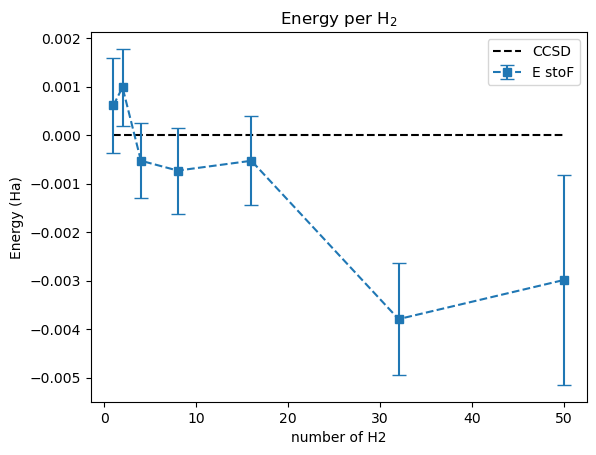

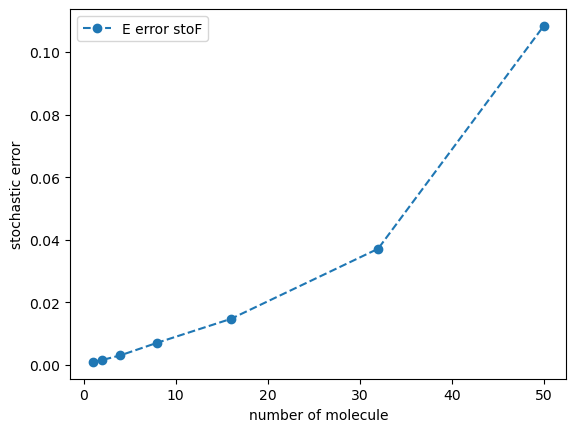

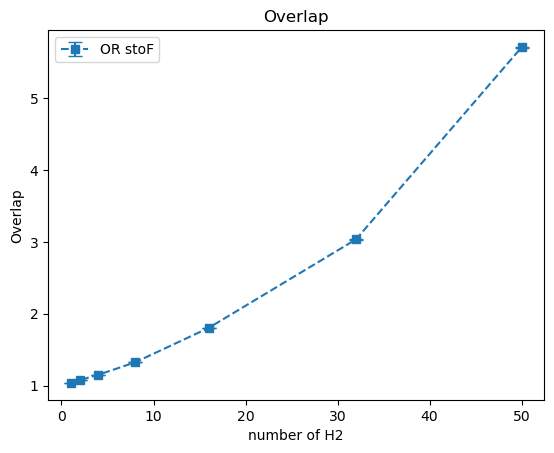

In [39]:
# AFQMC/stoFullCCSD
data = '''
# n_mol        E[CCSD]          <stoCCSD|H|HF>              overlap_ratio         
    1       -1.09607128     -1.095457 +/- 0.000983      1.037848 +/- 0.001341
    2       -2.19214256     -2.190165 +/- 0.001583      1.076456 +/- 0.001950
    4       -4.38428513     -4.386391 +/- 0.003085      1.149907 +/- 0.003473
    8       -8.76857026     -8.774408 +/- 0.007107      1.323035 +/- 0.006895
    16      -17.5371405     -17.545577 +/- 0.014731     1.803436 +/- 0.016682
    32      -35.0742810     -35.195683 +/- 0.037137     3.035901 +/- 0.068803
    50      -54.8035641     -54.952820 +/- 0.108332     5.713466 +/- 0.221056
'''

n = []
ccsd = []
stof = []
stof_err = []
stof_olp = []
stof_olp_err = []
for lines in data.splitlines():
    if not lines.startswith('#') and len(lines) > 0:
        parts = lines.split()
        n = np.hstack((n,int(parts[0])))
        ccsd = np.hstack((ccsd,float(parts[1])/int(parts[0])))
        stof = np.hstack((stof,float(parts[2])/int(parts[0])))
        stof_err = np.hstack((stof_err,float(parts[4])/int(parts[0])))
        stof_olp = np.hstack((stof_olp,float(parts[5])/int(parts[0])))
        stof_olp_err = np.hstack((stof_olp_err,float(parts[7])/int(parts[0])))

plt.plot(n,ccsd-ccsd,'--',color='black', label='CCSD')
plt.errorbar(n,stof-ccsd,yerr=stof_err,fmt='s--', capsize=5, color='C0', label='E stoF')
plt.xlabel('number of H2')
plt.ylabel('Energy (Ha)')
plt.title('Energy per H$_2$')
plt.legend()
plt.show()

plt.plot(n, n*stof_err, 'o--', color='C0', label='E error stoF')
plt.ylabel('stochastic error')
plt.xlabel('number of molecule')
plt.legend()
plt.show()

plt.errorbar(n,n*stof_olp,yerr=stof_olp_err,fmt='s--', capsize=5, color='C0', label='OR stoF')
plt.xlabel('number of H2')
plt.ylabel('Overlap')
plt.title('Overlap')
plt.legend()
plt.show()

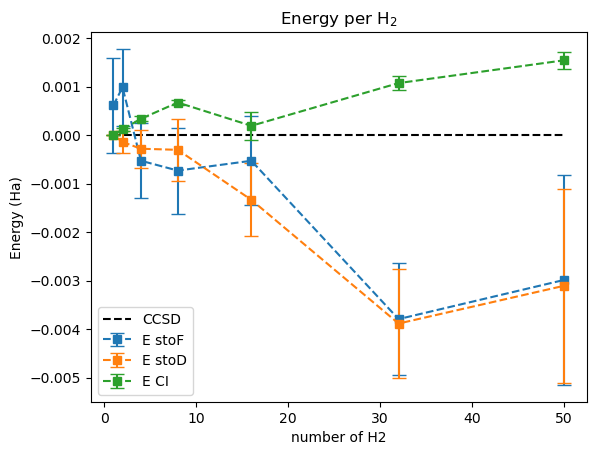

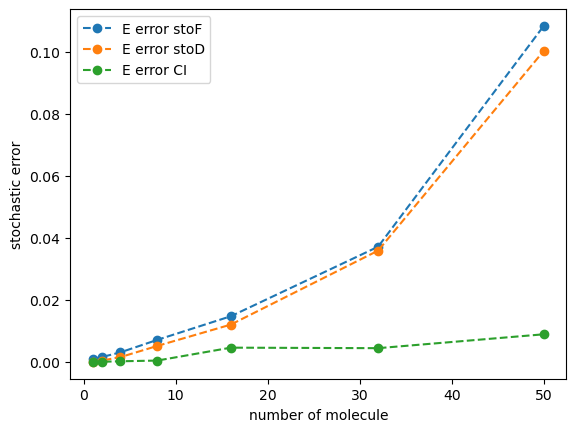

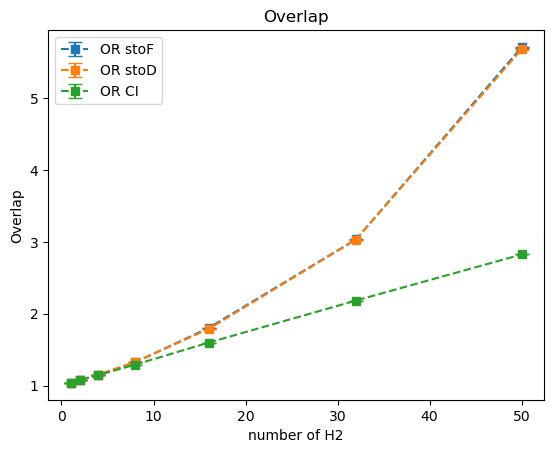

In [40]:
# AFQMC/stoDiffCCSD
data = '''
# n_mol        E[CCSD]          Energy/CI               Energy/CC           overlap[CI/HF]         overlap[CC/HF]
    1       -1.09607128     -1.096071 ± 0.000000    -1.096071 ± 0.000000    1.037429  0.001219    1.037429  0.001219
    2       -2.19214256     -2.191906 ± 0.000057    -2.192422 ± 0.000448    1.072035  0.000491    1.073790  0.000840
    4       -4.38428513     -4.382930 ± 0.000208    -4.385400 ± 0.001557    1.145647  0.000662    1.152883  0.001237
    8       -8.76857026     -8.763172 ± 0.000435    -8.770984 ± 0.005150    1.290246  0.001398    1.325932  0.003787
    16      -17.5371405     -17.534035 ± 0.004599   -17.558476 ± 0.012041   1.598251  0.003435    1.787228  0.012223
    32      -35.0742810     -35.039868 ± 0.004433   -35.198616 ± 0.035888   2.183646  0.008444    3.031949  0.060207
    50      -54.8035641     -54.726266 ± 0.008909   -54.958847 ± 0.100284   2.826237  0.005028    5.684358  0.214237
'''

n = []
ccsd = []
ci = []
ci_err = []
stod = []
stod_err = []
ci_olp = []
ci_olp_err = []
stod_olp = []
stod_olp_err = []
for lines in data.splitlines():
    if not lines.startswith('#') and len(lines) > 0:
        parts = lines.split()
        n = np.hstack((n,int(parts[0])))
        ccsd = np.hstack((ccsd,float(parts[1])/int(parts[0])))
        ci = np.hstack((ci,float(parts[2])/int(parts[0])))
        ci_err = np.hstack((ci_err,float(parts[4])/int(parts[0])))
        stod = np.hstack((stod,float(parts[5])/int(parts[0])))
        stod_err = np.hstack((stod_err,float(parts[7])/int(parts[0])))
        ci_olp = np.hstack((ci_olp,float(parts[8])/int(parts[0])))
        ci_olp_err = np.hstack((ci_olp_err,float(parts[9])/int(parts[0])))
        stod_olp = np.hstack((stod_olp,float(parts[10])/int(parts[0])))
        stod_olp_err = np.hstack((stod_olp_err,float(parts[11])/int(parts[0])))

plt.plot(n,ccsd-ccsd,'--',color='black', label='CCSD')
plt.errorbar(n,stof-ccsd,yerr=stof_err,fmt='s--', capsize=5, color='C0', label='E stoF')
plt.errorbar(n,stod-ccsd,yerr=stod_err,fmt='s--', capsize=5, color='C1', label='E stoD')
plt.errorbar(n,ci-ccsd,yerr=ci_err,fmt='s--', capsize=5, color='C2', label='E CI')
plt.xlabel('number of H2')
plt.ylabel('Energy (Ha)')
plt.title('Energy per H$_2$')
plt.legend()
plt.show()

plt.plot(n, n*stof_err, 'o--', color='C0', label='E error stoF')
plt.plot(n, n*stod_err, 'o--', color='C1', label='E error stoD')
plt.plot(n, n*ci_err, 'o--', color='C2', label='E error CI')
plt.ylabel('stochastic error')
plt.xlabel('number of molecule')
plt.legend()
plt.show()

plt.errorbar(n,n*stof_olp,yerr=stof_olp_err,fmt='s--', capsize=5, color='C0', label='OR stoF')
plt.errorbar(n,n*stod_olp,yerr=stod_olp_err,fmt='s--', capsize=5, color='C1', label='OR stoD')
plt.errorbar(n,n*ci_olp,yerr=ci_olp_err,fmt='s--', capsize=5, color='C2', label='OR CI')
plt.xlabel('number of H2')
plt.ylabel('Overlap')
plt.title('Overlap')
plt.legend()
plt.show()

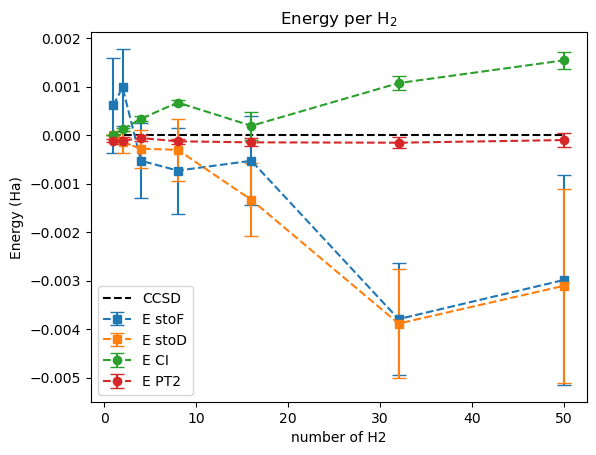

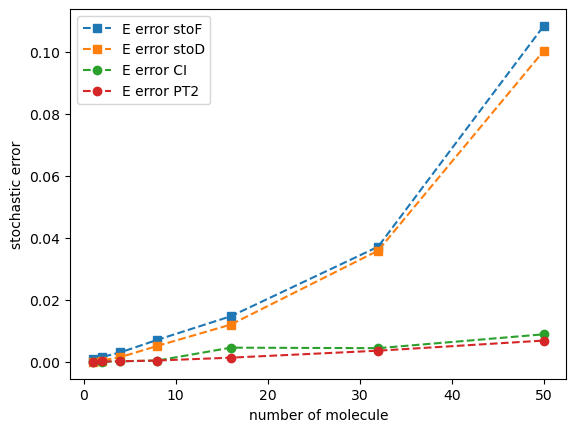

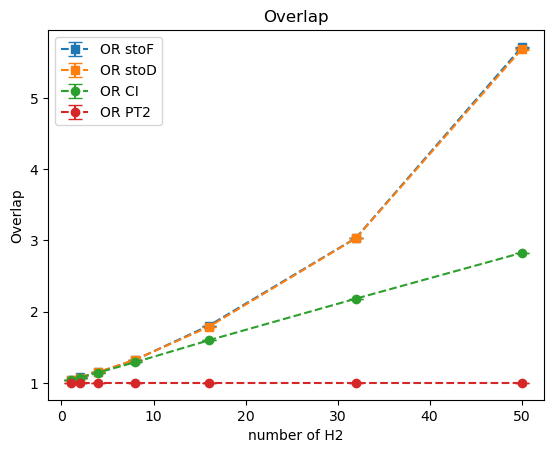

In [41]:
# AFQMC/pt2CCSD
data = '''
# n_mol        E[CCSD]          <pt2CCSD|H|HF>              overlap_ratio         
    1       -1.09607128     -1.096181 ± 0.000027        1.000000 ± 0.000000
    2       -2.19214256     -2.192372 ± 0.000139        1.000000 ± 0.000000
    4       -4.38428513     -4.384520 ± 0.000219        1.000000 ± 0.000000
    8       -8.76857026     -8.769575 ± 0.000451        1.000000 ± 0.000000
    16      -17.5371405     -17.539492 ± 0.001374       1.000000 ± 0.000000
    32      -35.0742810     -35.079224 ± 0.003619       1.000000 ± 0.000000
    50      -54.8035641     -54.808565 ± 0.006888       1.000000 ± 0.000000
'''

n = []
ccsd = []
pt2 = []
pt2_err = []
pt2_olp = []
pt2_olp_err = []
for lines in data.splitlines():
    if not lines.startswith('#') and len(lines) > 0:
        parts = lines.split()
        n = np.hstack((n,int(parts[0])))
        ccsd = np.hstack((ccsd,float(parts[1])/int(parts[0])))
        pt2 = np.hstack((pt2,float(parts[2])/int(parts[0])))
        pt2_err = np.hstack((pt2_err,float(parts[4])/int(parts[0])))
        pt2_olp = np.hstack((pt2_olp,float(parts[5])/int(parts[0])))
        pt2_olp_err = np.hstack((pt2_olp_err,float(parts[7])/int(parts[0])))

plt.plot(n,ccsd-ccsd,'--',color='black', label='CCSD')
plt.errorbar(n,stof-ccsd,yerr=stof_err,fmt='s--', capsize=5, color='C0', label='E stoF')
plt.errorbar(n,stod-ccsd,yerr=stod_err,fmt='s--', capsize=5, color='C1', label='E stoD')
plt.errorbar(n,ci-ccsd,yerr=ci_err,fmt='o--', capsize=5, color='C2', label='E CI')
plt.errorbar(n,pt2-ccsd,yerr=pt2_err,fmt='o--', capsize=5, color='C3', label='E PT2')
plt.xlabel('number of H2')
plt.ylabel('Energy (Ha)')
plt.title('Energy per H$_2$')
plt.legend()
plt.show()

plt.plot(n, n*stof_err, 's--', color='C0', label='E error stoF')
plt.plot(n, n*stod_err, 's--', color='C1', label='E error stoD')
plt.plot(n, n*ci_err, 'o--', color='C2', label='E error CI')
plt.plot(n, n*pt2_err, 'o--', color='C3', label='E error PT2')
plt.ylabel('stochastic error')
plt.xlabel('number of molecule')
plt.legend()
plt.show()

plt.errorbar(n,n*stof_olp,yerr=stof_olp_err,fmt='s--', capsize=5, color='C0', label='OR stoF')
plt.errorbar(n,n*stod_olp,yerr=stod_olp_err,fmt='s--', capsize=5, color='C1', label='OR stoD')
plt.errorbar(n,n*ci_olp,yerr=ci_olp_err,fmt='o--', capsize=5, color='C2', label='OR CI')
plt.errorbar(n,n*pt2_olp,yerr=pt2_olp_err,fmt='o--', capsize=5, color='C3', label='OR PT2')
plt.xlabel('number of H2')
plt.ylabel('Overlap')
plt.title('Overlap')
plt.legend()
plt.show()

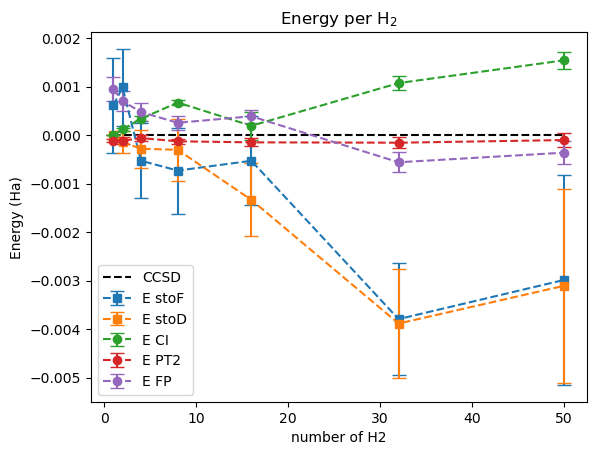

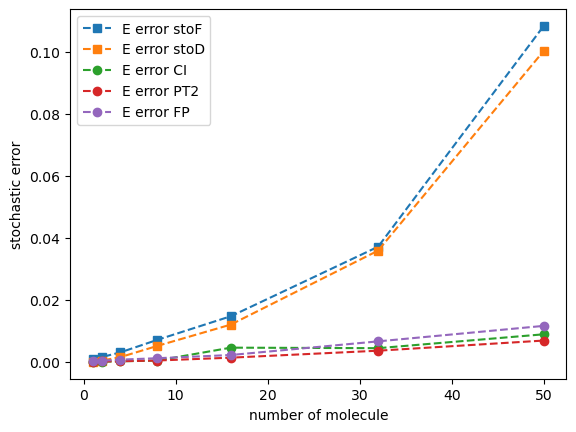

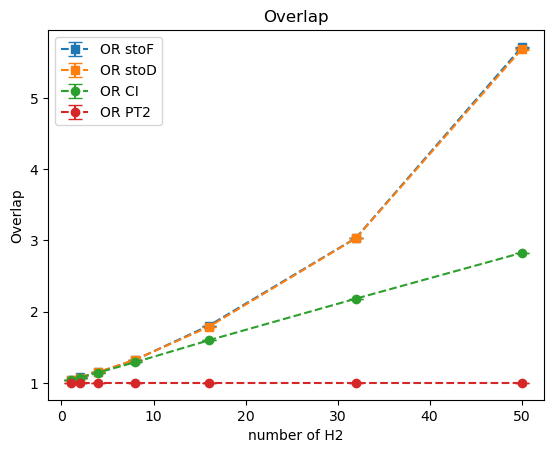

In [49]:
# AFQMC/pt2CCSD
data = '''
# n_mol        E[CCSD]          fpAFQMC/HF              
    1       -1.09607128     -1.095122 ± 0.000246       
    2       -2.19214256     -2.190734 ± 0.000407       
    4       -4.38428513     -4.382374 ± 0.000733     
    8       -8.76857026     -8.766518 ± 0.001192        
    16      -17.5371405     -17.530891 ± 0.002226      
   32      -35.0742810     -35.092142 ± 0.006627     
   50      -54.8035641    -54.821553 ± 0.011624
'''

nfp = []
fp = []
fp_err = []
for lines in data.splitlines():
    if not lines.startswith('#') and len(lines) > 0:
        parts = lines.split()
        nfp = np.hstack((nfp,int(parts[0])))
        # ccsd = np.hstack((ccsd,float(parts[1])/int(parts[0])))
        fp = np.hstack((fp,float(parts[2])/int(parts[0])))
        fp_err = np.hstack((fp_err,float(parts[4])/int(parts[0])))

plt.plot(n,ccsd-ccsd,'--',color='black', label='CCSD')
plt.errorbar(n,stof-ccsd,yerr=stof_err,fmt='s--', capsize=5, color='C0', label='E stoF')
plt.errorbar(n,stod-ccsd,yerr=stod_err,fmt='s--', capsize=5, color='C1', label='E stoD')
plt.errorbar(n,ci-ccsd,yerr=ci_err,fmt='o--', capsize=5, color='C2', label='E CI')
plt.errorbar(n,pt2-ccsd,yerr=pt2_err,fmt='o--', capsize=5, color='C3', label='E PT2')
plt.errorbar(nfp,fp-ccsd[:len(nfp)],yerr=fp_err,fmt='o--', capsize=5, color='C4', label='E FP')
plt.xlabel('number of H2')
plt.ylabel('Energy (Ha)')
plt.title('Energy per H$_2$')
plt.legend()
plt.show()

plt.plot(n, n*stof_err, 's--', color='C0', label='E error stoF')
plt.plot(n, n*stod_err, 's--', color='C1', label='E error stoD')
plt.plot(n, n*ci_err, 'o--', color='C2', label='E error CI')
plt.plot(n, n*pt2_err, 'o--', color='C3', label='E error PT2')
plt.plot(nfp, nfp*fp_err, 'o--', color='C4', label='E error FP')
plt.ylabel('stochastic error')
plt.xlabel('number of molecule')
plt.legend()
plt.show()

plt.errorbar(n,n*stof_olp,yerr=stof_olp_err,fmt='s--', capsize=5, color='C0', label='OR stoF')
plt.errorbar(n,n*stod_olp,yerr=stod_olp_err,fmt='s--', capsize=5, color='C1', label='OR stoD')
plt.errorbar(n,n*ci_olp,yerr=ci_olp_err,fmt='o--', capsize=5, color='C2', label='OR CI')
plt.errorbar(n,n*pt2_olp,yerr=pt2_olp_err,fmt='o--', capsize=5, color='C3', label='OR PT2')
plt.xlabel('number of H2')
plt.ylabel('Overlap')
plt.title('Overlap')
plt.legend()
plt.show()

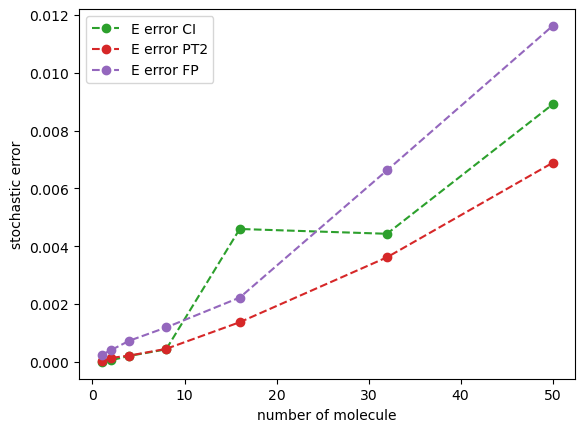

In [51]:
plt.plot(n, n*ci_err, 'o--', color='C2', label='E error CI')
plt.plot(n, n*pt2_err, 'o--', color='C3', label='E error PT2')
plt.plot(nfp, nfp*fp_err, 'o--', color='C4', label='E error FP')
plt.ylabel('stochastic error')
plt.xlabel('number of molecule')
plt.legend()
plt.show()

In [29]:
data = '''
1.000     -2100.168071264         1.56e-03        0.96
2.000     -2100.172506877         1.14e-03        0.91
3.000     -2100.171392124         1.75e-03        0.85
4.000     -2100.171902006         1.02e-03        0.78
5.000     -2100.171925892         1.95e-03        0.71
6.000     -2100.172031373         3.23e-03        0.63
7.000     -2100.167584659         2.78e-03        0.56
'''

arr = np.loadtxt(data.strip().splitlines())
tau = arr[:, 0]
energy = arr[:, 1]
d_energy = arr[:, 2]


In [33]:
E_inf, dE_inf = fit_fp_decay(tau,energy,d_energy,save_plot=True)

  Exponential-Energy Cooling fit:  E(beta) = E_inf + A exp(-Gamma*beta)
  E_inf   = -2100.171810 ± 0.000750
  A       = 0.879812 ± 459.403942
  Gamma   = 5.4642 ± 521.7710
  System cooled to about 37% initial Energy gap at beta = 0.1830 a.u. (1/Gamma)
  System considered fully cooled at about beta = [0.5490, 0.9150] a.u.


  Exponential-plateau fit:  E(τ) = E∞ + A exp(-γτ)
  E∞    = -2100.171810 ± 0.000750
  A     = 0.881064 ± 460.056061
  γ     = 5.4656 ± 521.8946
  Transient < 1σ(E∞) for τ > 1.29

  Weighted-mean cross-check (tail with τ ≥ 4.0):
  E_tail = -2100.171529 ± 0.000831
  χ²/dof = 0.74  (dof = 3)

  ✓ Plateau reached: the exponential transient has died out
    within the data window (τ_plateau ≈ 1.3).

  ➤  Ground-state energy estimate:  E₀ = -2100.171810 ± 0.000750


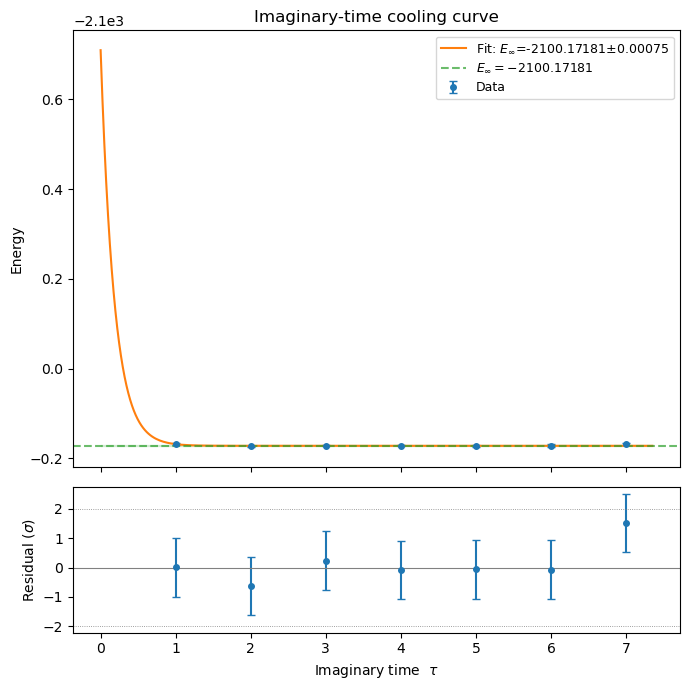

In [ ]:
def exp_plateau(tau, E_inf, A, gamma):
    return E_inf + A * np.exp(-gamma * tau)

# Initial guesses: E_inf ~ last few points, A ~ E(0)-E_inf, gamma ~ 1
p0 = [-2100.167584659, 0.04, 1.0]

popt, pcov = curve_fit(exp_plateau, tau, energy, p0=p0,
                       sigma=d_energy, absolute_sigma=True,
                       maxfev=10000)

E_inf, A, gamma = popt
perr = np.sqrt(np.diag(pcov))
dE_inf, dA, dgamma = perr

# ── Plateau diagnostic ───────────────────────────────────────────────
# The signal has "cooled" when exp(-gamma * tau) is negligible.
# Define plateau as the region where the transient < 1 sigma of E_inf.
tau_plateau = -np.log(dE_inf / abs(A)) / gamma if abs(A) > dE_inf else 0.0

# Also do a simple weighted mean of the "flat" tail as a cross-check.
# Use points beyond tau_plateau (or at least the last half).
tail_mask = tau >= max(tau_plateau, tau[-1] / 2)
w = 1.0 / d_energy[tail_mask]**2
E_tail = np.sum(energy[tail_mask] * w) / np.sum(w)
dE_tail = 1.0 / np.sqrt(np.sum(w))

# Chi-squared of the tail relative to its weighted mean
chi2_tail = np.sum(((energy[tail_mask] - E_tail) / d_energy[tail_mask])**2)
ndof_tail = np.sum(tail_mask) - 1
chi2_red = chi2_tail / ndof_tail if ndof_tail > 0 else np.nan

# ── Report ────────────────────────────────────────────────────────────
print("=" * 60)
print("  Exponential-plateau fit:  E(τ) = E∞ + A exp(-γτ)")
print("=" * 60)
print(f"  E∞    = {E_inf:.6f} ± {dE_inf:.6f}")
print(f"  A     = {A:.6f} ± {dA:.6f}")
print(f"  γ     = {gamma:.4f} ± {dgamma:.4f}")
print(f"  Transient < 1σ(E∞) for τ > {tau_plateau:.2f}")
print()
print("  Weighted-mean cross-check (tail with τ ≥ {:.1f}):".format(
    tau[tail_mask][0]))
print(f"  E_tail = {E_tail:.6f} ± {dE_tail:.6f}")
print(f"  χ²/dof = {chi2_red:.2f}  (dof = {ndof_tail})")
print()

if tau_plateau < tau[-1]:
    print("  ✓ Plateau reached: the exponential transient has died out")
    print(f"    within the data window (τ_plateau ≈ {tau_plateau:.1f}).")
else:
    print("  ✗ Plateau NOT convincingly reached — consider longer τ.")

print()
print(f"  ➤  Ground-state energy estimate:  E₀ = {E_inf:.6f} ± {dE_inf:.6f}")
print("=" * 60)

# ── Plot ──────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

tau_fine = np.linspace(0, tau[-1] * 1.05, 300)
ax1.errorbar(tau, energy, yerr=d_energy, fmt='o', ms=4, capsize=3,
             color='C0', label='Data')
ax1.plot(tau_fine, exp_plateau(tau_fine, *popt), '-', color='C1',
         label=rf'Fit: $E_\infty$={E_inf:.5f}±{dE_inf:.5f}')
ax1.axhline(E_inf, ls='--', color='C2', alpha=0.7,
            label=rf'$E_\infty = {E_inf:.5f}$')
ax1.fill_between(tau_fine, E_inf - dE_inf, E_inf + dE_inf,
                 color='C2', alpha=0.15)
ax1.set_ylabel('Energy')
ax1.set_title('Imaginary-time cooling curve')
ax1.legend(fontsize=9)

# Residuals
residuals = (energy - exp_plateau(tau, *popt)) / d_energy
ax2.errorbar(tau, residuals, yerr=1, fmt='o', ms=4, capsize=3, color='C0')
ax2.axhline(0, ls='-', color='gray', lw=0.8)
ax2.axhline(2, ls=':', color='gray', lw=0.6)
ax2.axhline(-2, ls=':', color='gray', lw=0.6)
ax2.set_xlabel(r'Imaginary time  $\tau$')
ax2.set_ylabel(r'Residual ($\sigma$)')
plt.tight_layout()

In [2]:
data = '''
2.000     -2099.915543391         4.13e-04        0.88
4.000     -2099.917552736         6.37e-04        0.72
6.000     -2099.918696669         9.21e-04        0.55
8.000     -2099.920150898         1.78e-03        0.40
10.000     -2099.921350137         1.91e-03        0.27
12.000     -2099.920744324         2.42e-03        0.19
'''

arr = np.loadtxt(data.strip().splitlines())
tau = arr[:, 0]
energy = arr[:, 1]
d_energy = arr[:, 2]


In [12]:
energy[0]-energy[-1]

np.float64(0.005200933000196528)

  Exponential-Energy Cooling fit:  E(beta) = E_inf + A exp(-Gamma*beta)
  E_inf   = -2099.922943 ± 0.005320
  A       = 0.010017 ± 0.004054
  Gamma   = 0.1518 ± 0.1648
  System cooled to about 37% initial Energy gap at beta = 6.5873 a.u. (1/Gamma)
  System considered fully cooled at about beta = [19.7620, 32.9367] a.u.

  !!!System NOT convincingly cooled — consider longer propagation.
  Ground-state energy estimate:  E_inf = -2099.922943 ± 0.005320


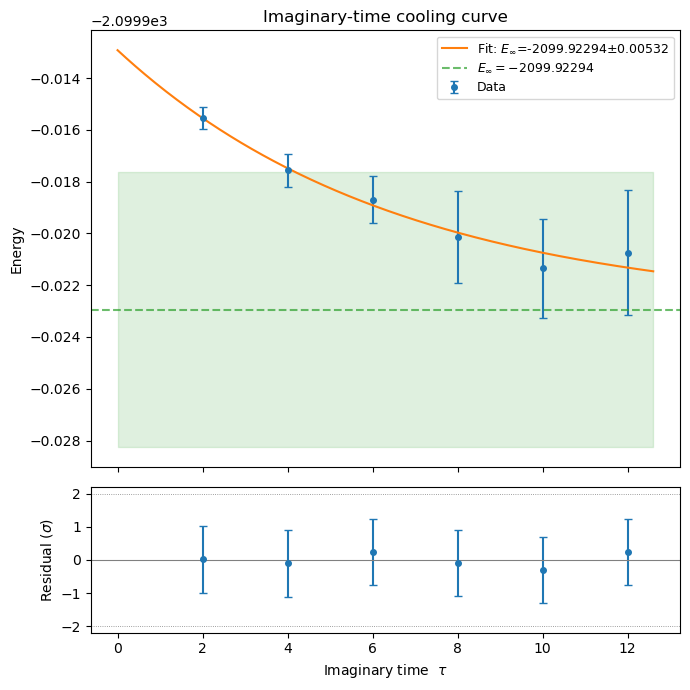

In [33]:
def exp_plateau(tau, E_inf, A, gamma):
    return E_inf + A * np.exp(-gamma * tau)

# Initial guesses: E_inf ~ last points, A ~ E(0)-E_inf, gamma ~ 0.5
p0 = [energy[-1], energy[0]-energy[-1], 0.3]

popt, pcov = curve_fit(exp_plateau, tau, energy, p0=p0,
                       sigma=d_energy, absolute_sigma=True,
                       maxfev=10000)

E_inf, A, gamma = popt
perr = np.sqrt(np.diag(pcov))
dE_inf, dA, dgamma = perr

# ── Plateau diagnostic ───────────────────────────────────────────────
# The signal has "cooled" when exp(-gamma * tau) is negligible.
# Define plateau as the region where the transient < 1 sigma of E_inf.
# tau_plateau = -np.log(dE_inf / abs(A)) / gamma if abs(A) > dE_inf else 0.0

# # Also do a simple weighted mean of the "flat" tail as a cross-check.
# # Use points beyond tau_plateau (or at least the last half).
# tail_mask = tau >= max(tau_plateau, tau[-1] / 2)
# w = 1.0 / d_energy[tail_mask]**2
# E_tail = np.sum(energy[tail_mask] * w) / np.sum(w)
# dE_tail = 1.0 / np.sqrt(np.sum(w))

# # Chi-squared of the tail relative to its weighted mean
# chi2_tail = np.sum(((energy[tail_mask] - E_tail) / d_energy[tail_mask])**2)
# ndof_tail = np.sum(tail_mask) - 1
# chi2_red = chi2_tail / ndof_tail if ndof_tail > 0 else np.nan

# ── Report ────────────────────────────────────────────────────────────
print("=" * 80)
print("  Exponential-Energy Cooling fit:  E(beta) = E_inf + A exp(-Gamma*beta)")
print("=" * 80)
print(f"  E_inf   = {E_inf:.6f} ± {dE_inf:.6f}")
print(f"  A       = {A:.6f} ± {dA:.6f}")
print(f"  Gamma   = {gamma:.4f} ± {dgamma:.4f}")
print(f"  System cooled to about 37% initial Energy gap at beta = {1/gamma:.4f} a.u. (1/Gamma)")
print(f"  System considered fully cooled at about beta = [{3/gamma:.4f}, {5/gamma:.4f}] a.u.")
print()

if 3/gamma < tau[-1]:
    print("  System cooled: the exponential transient has died out")
else:
    print("  !!!System NOT convincingly cooled — consider longer propagation.")

# print()
print(f"  Ground-state energy estimate:  E_inf = {E_inf:.6f} ± {dE_inf:.6f}")
print("=" * 80)

# ── Plot ──────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

tau_fine = np.linspace(0, tau[-1] * 1.05, 300)
ax1.errorbar(tau, energy, yerr=d_energy, fmt='o', ms=4, capsize=3,
             color='C0', label='Data')
ax1.plot(tau_fine, exp_plateau(tau_fine, *popt), '-', color='C1',
         label=rf'Fit: $E_\infty$={E_inf:.5f}±{dE_inf:.5f}')
ax1.axhline(E_inf, ls='--', color='C2', alpha=0.7,
            label=rf'$E_\infty = {E_inf:.5f}$')
ax1.fill_between(tau_fine, E_inf - dE_inf, E_inf + dE_inf,
                 color='C2', alpha=0.15)
ax1.set_ylabel('Energy')
ax1.set_title('Imaginary-time cooling curve')
ax1.legend(fontsize=9)

# Residuals
residuals = (energy - exp_plateau(tau, *popt)) / d_energy
ax2.errorbar(tau, residuals, yerr=1, fmt='o', ms=4, capsize=3, color='C0')
ax2.axhline(0, ls='-', color='gray', lw=0.8)
ax2.axhline(2, ls=':', color='gray', lw=0.6)
ax2.axhline(-2, ls=':', color='gray', lw=0.6)
ax2.set_xlabel(r'Imaginary time  $\tau$')
ax2.set_ylabel(r'Residual ($\sigma$)')

plt.tight_layout()

In [11]:
data = '''
  0.00    -1.05643   0.00010    632.42
  0.50    -1.07218   0.00015    638.68
  1.00    -1.08188   0.00029    638.68
  1.50    -1.08789   0.00038    638.68
  2.00    -1.09156   0.00043    638.68
  2.50    -1.09336   0.00059    638.68
  3.00    -1.09401   0.00051    638.68
  3.50    -1.09381   0.00053    638.68
  4.00    -1.09466   0.00058    638.68
  4.50    -1.09453   0.00059    638.68
  5.00    -1.09493   0.00055    638.68
  5.50    -1.09526   0.00065    638.68
  6.00    -1.09499   0.00061    638.68
'''

arr = np.loadtxt(data.strip().splitlines())
tau = arr[1:, 0]
energy = arr[1:, 1]
d_energy = arr[1:, 2]


  Exponential-Energy Cooling fit:  E(beta) = E_inf + A exp(-Gamma*beta)
  E_inf   = -1.095118 ± 0.000246
  A       = 0.040815 ± 0.000752
  Gamma   = 1.1498 ± 0.0416
  System cooled to about 37% initial Energy gap at beta = 0.8697 a.u. (1/Gamma)
  System considered fully cooled at about beta = [2.6091, 4.3484] a.u.

  System cooled: the exponential transient has died out
  Ground-state energy estimate:  E_inf = -1.095118 ± 0.000246


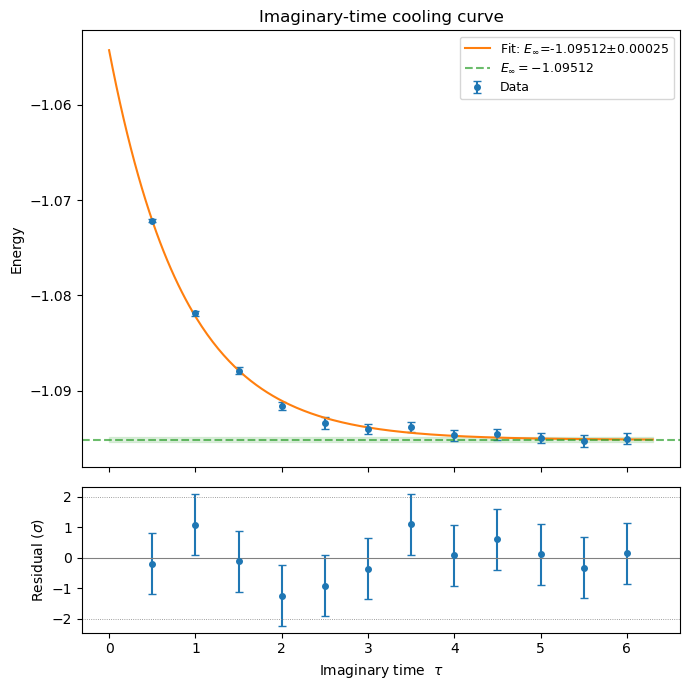

In [12]:
def exp_plateau(tau, E_inf, A, gamma):
    return E_inf + A * np.exp(-gamma * tau)

# Initial guesses: E_inf ~ last points, A ~ E(0)-E_inf, gamma ~ 0.5
p0 = [energy[-1], energy[0]-energy[-1], 1]

popt, pcov = curve_fit(exp_plateau, tau, energy, p0=p0,
                       sigma=d_energy, absolute_sigma=True,
                       maxfev=10000)

E_inf, A, gamma = popt
perr = np.sqrt(np.diag(pcov))
dE_inf, dA, dgamma = perr

# ── Report ────────────────────────────────────────────────────────────
print("=" * 80)
print("  Exponential-Energy Cooling fit:  E(beta) = E_inf + A exp(-Gamma*beta)")
print("=" * 80)
print(f"  E_inf   = {E_inf:.6f} ± {dE_inf:.6f}")
print(f"  A       = {A:.6f} ± {dA:.6f}")
print(f"  Gamma   = {gamma:.4f} ± {dgamma:.4f}")
print(f"  System cooled to about 37% initial Energy gap at beta = {1/gamma:.4f} a.u. (1/Gamma)")
print(f"  System considered fully cooled at about beta = [{3/gamma:.4f}, {5/gamma:.4f}] a.u.")
print()

if 3/gamma < tau[-1]:
    print("  System cooled: the exponential transient has died out")
else:
    print("  !!!System NOT convincingly cooled — consider longer propagation.")

# print()
print(f"  Ground-state energy estimate:  E_inf = {E_inf:.6f} ± {dE_inf:.6f}")
print("=" * 80)

# ── Plot ──────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

tau_fine = np.linspace(0, tau[-1] * 1.05, 300)
ax1.errorbar(tau, energy, yerr=d_energy, fmt='o', ms=4, capsize=3,
             color='C0', label='Data')
ax1.plot(tau_fine, exp_plateau(tau_fine, *popt), '-', color='C1',
         label=rf'Fit: $E_\infty$={E_inf:.5f}±{dE_inf:.5f}')
ax1.axhline(E_inf, ls='--', color='C2', alpha=0.7,
            label=rf'$E_\infty = {E_inf:.5f}$')
ax1.fill_between(tau_fine, E_inf - dE_inf, E_inf + dE_inf,
                 color='C2', alpha=0.15)
ax1.set_ylabel('Energy')
ax1.set_title('Imaginary-time cooling curve')
ax1.legend(fontsize=9)

# Residuals
residuals = (energy - exp_plateau(tau, *popt)) / d_energy
ax2.errorbar(tau, residuals, yerr=1, fmt='o', ms=4, capsize=3, color='C0')
ax2.axhline(0, ls='-', color='gray', lw=0.8)
ax2.axhline(2, ls=':', color='gray', lw=0.6)
ax2.axhline(-2, ls=':', color='gray', lw=0.6)
ax2.set_xlabel(r'Imaginary time  $\tau$')
ax2.set_ylabel(r'Residual ($\sigma$)')

plt.tight_layout()